# Analyse exploratoire des données Olist

## Projet : Analyse des ventes et prédiction de la satisfaction client sur la plateforme e-commerce Olist

Ce notebook présente une première analyse exploratoire des 9 datasets du projet Olist.

Objectifs :
- charger les datasets ;
- observer leurs dimensions ;
- afficher les premières lignes ;
- analyser les valeurs manquantes ;
- afficher les statistiques descriptives ;
- produire quelques graphiques simples pour comprendre les données.

À ce stade, aucun nettoyage avancé n'est effectué.

## 1. Importation des bibliothèques

In [1]:
# On importe pandas pour manipuler les tableaux de données.
import pandas as pd

# On importe numpy pour les calculs numériques.
import numpy as np

# On importe matplotlib pour créer des graphiques simples.
import matplotlib.pyplot as plt

# On importe seaborn pour créer des graphiques plus lisibles.
import seaborn as sns

## 2. Chargement des 9 datasets

In [2]:
# Chargement du dataset des clients.
customers = pd.read_csv("olist_customers_dataset.csv")

# Chargement du dataset de géolocalisation.
geolocation = pd.read_csv("olist_geolocation_dataset.csv")

# Chargement du dataset des articles commandés.
order_items = pd.read_csv("olist_order_items_dataset.csv")

# Chargement du dataset des paiements.
order_payments = pd.read_csv("olist_order_payments_dataset.csv")

# Chargement du dataset des avis clients.
order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")

# Chargement du dataset des commandes.
orders = pd.read_csv("olist_orders_dataset.csv")

# Chargement du dataset des produits.
products = pd.read_csv("olist_products_dataset.csv")

# Chargement du dataset des vendeurs.
sellers = pd.read_csv("olist_sellers_dataset.csv")

# Chargement du dataset de traduction des catégories de produits.
translation = pd.read_csv("olist_product_category_name_translation.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'olist_customers_dataset.csv'

## 3. Création d'un dictionnaire des datasets

In [ ]:
# Ce dictionnaire permet de parcourir facilement tous les datasets.
datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "translation": translation
}

NameError: name 'customers' is not defined

## 4. Dimensions des datasets

In [ ]:
# On affiche le nombre de lignes et de colonnes de chaque dataset.
for name, df in datasets.items():
    print(name, "->", df.shape)

customers -> (99441, 5)
geolocation -> (1000163, 5)
order_items -> (112650, 7)
order_payments -> (103886, 5)
order_reviews -> (99224, 7)
orders -> (99441, 8)
products -> (32951, 9)
sellers -> (3095, 4)
translation -> (71, 2)


## 5. Aperçu des premières lignes

In [ ]:
# Exemple d'affichage des premières lignes du dataset des commandes.
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
geolocation.head(20)

NameError: name 'geolocation' is not defined

In [ ]:
# Exemple d'affichage des premières lignes du dataset des avis clients.
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
# Exemple d'affichage des premières lignes du dataset des paiements.
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


## 6. Types de données

In [ ]:
# On affiche les types de colonnes pour chaque dataset.
for name, df in datasets.items():
    print("=" * 60)
    print("Dataset :", name)
    print("=" * 60)
    print(df.dtypes)
    print("\n")

Dataset : customers
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object


Dataset : geolocation
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object


Dataset : order_items
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object


Dataset : order_payments
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object


Dataset : order_reviews
review_id                  object
order_id                   object
review_s

## 7. Valeurs manquantes

In [ ]:
# On calcule le nombre de valeurs manquantes dans chaque colonne de chaque dataset.
for name, df in datasets.items():
    print("=" * 60)
    print("Valeurs manquantes dans :", name)
    print("=" * 60)
    print(df.isnull().sum())
    print("\n")

Valeurs manquantes dans : customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


Valeurs manquantes dans : geolocation
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


Valeurs manquantes dans : order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


Valeurs manquantes dans : order_payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


Valeurs manquantes dans : order_reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       8

## 8. Doublons

In [ ]:
# On calcule le nombre de lignes totalement dupliquées dans chaque dataset.
for name, df in datasets.items():
    print(name, "->", df.duplicated().sum(), "doublons")

customers -> 0 doublons
geolocation -> 261831 doublons
order_items -> 0 doublons
order_payments -> 0 doublons
order_reviews -> 0 doublons
orders -> 0 doublons
products -> 0 doublons
sellers -> 0 doublons
translation -> 0 doublons


## 9. Statistiques descriptives générales

In [ ]:
# On affiche les statistiques descriptives pour les colonnes numériques.
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [ ]:
# Statistiques descriptives du dataset des paiements.
order_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [ ]:
# Statistiques descriptives du dataset des avis clients.
order_reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


## 10. Analyse du statut des commandes

In [ ]:
# On compte le nombre de commandes par statut.
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

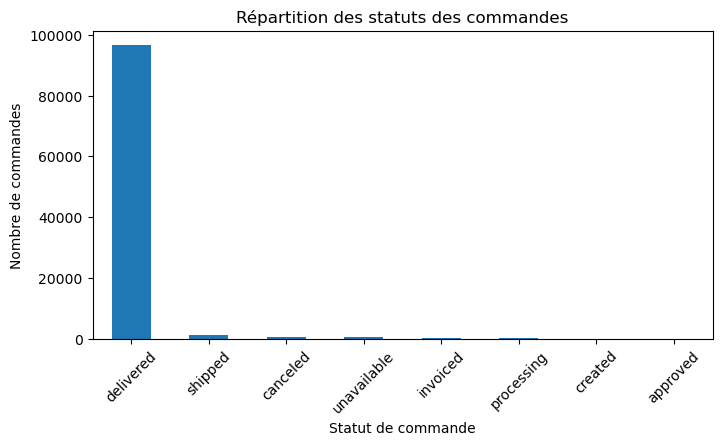

In [ ]:
# Graphique simple de la répartition des statuts de commandes.
orders["order_status"].value_counts().plot(kind="bar", figsize=(8, 4))
plt.title("Répartition des statuts des commandes")
plt.xlabel("Statut de commande")
plt.ylabel("Nombre de commandes")
plt.xticks(rotation=45)
plt.show()

**Interprétation :**  
Ce graphique permet d'observer la répartition des commandes selon leur statut. On constate que la majorité des commandes ont bien été livrées.

## 11. Analyse des notes de satisfaction

In [ ]:
# On compte le nombre d'avis pour chaque note de satisfaction.
order_reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

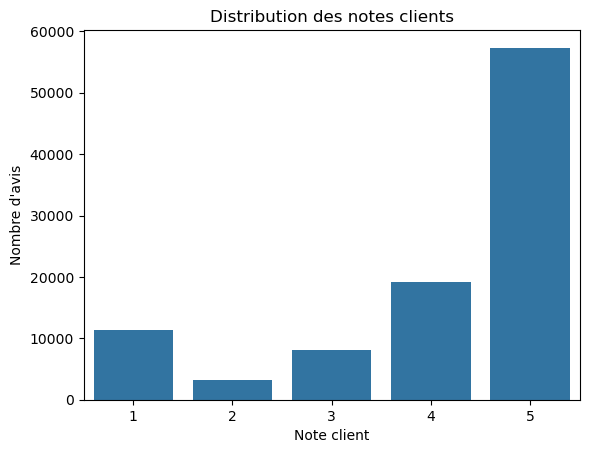

In [ ]:
# Graphique simple de la distribution des notes clients.
sns.countplot(x="review_score", data=order_reviews)
plt.title("Distribution des notes clients")
plt.xlabel("Note client")
plt.ylabel("Nombre d'avis")
plt.show()

**Interprétation :**  
Cette analyse permet d'évaluer la satisfaction globale des clients. La note `review_score` sera importante pour la suite du projet, car elle peut servir de variable cible pour prédire la satisfaction client.

## 12. Analyse des modes de paiement

In [ ]:
# On compte les différents types de paiement utilisés.
order_payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

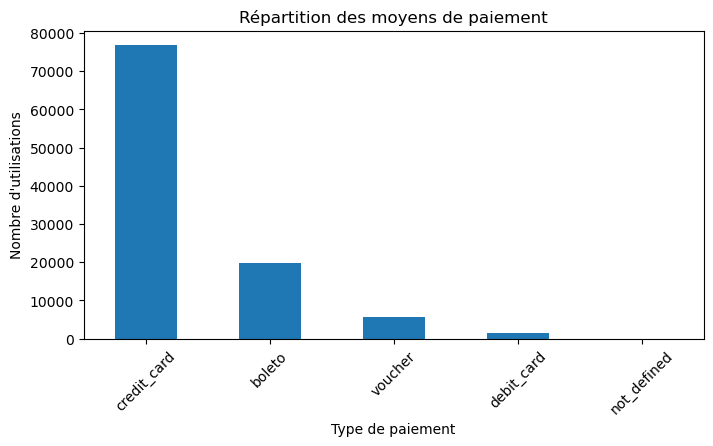

In [ ]:
# Graphique des moyens de paiement.
order_payments["payment_type"].value_counts().plot(kind="bar", figsize=(8, 4))
plt.title("Répartition des moyens de paiement")
plt.xlabel("Type de paiement")
plt.ylabel("Nombre d'utilisations")
plt.xticks(rotation=45)
plt.show()

**Interprétation :**  
Cette analyse permet d'identifier les moyens de paiement les plus utilisés par les clients de la plateforme.

## 13. Analyse des prix des articles

In [ ]:
# Statistiques descriptives sur le prix des articles.
order_items["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

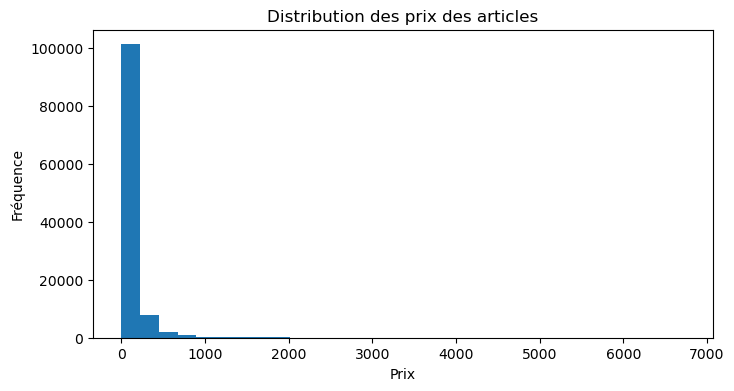

In [ ]:
# Histogramme des prix des articles.
plt.figure(figsize=(8, 4))
plt.hist(order_items["price"], bins=30)
plt.title("Distribution des prix des articles")
plt.xlabel("Prix")
plt.ylabel("Fréquence")
plt.show()

**Interprétation :**  
L'histogramme permet d'observer la répartition des prix des articles et d'identifier la présence éventuelle de valeurs très élevées.

## 14. Analyse des frais de livraison

In [ ]:
# Statistiques descriptives sur les frais de livraison.
order_items["freight_value"].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

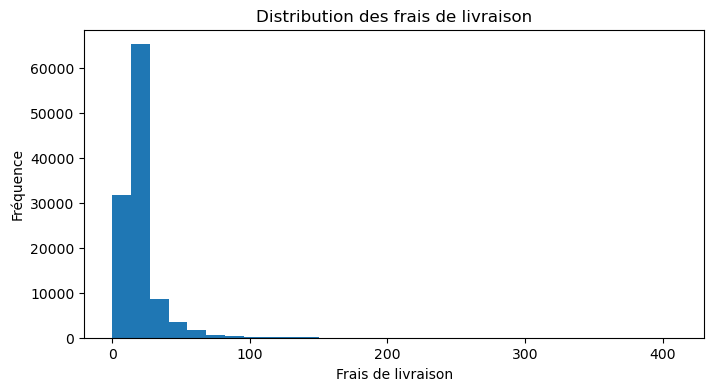

In [ ]:
# Histogramme des frais de livraison.
plt.figure(figsize=(8, 4))
plt.hist(order_items["freight_value"], bins=30)
plt.title("Distribution des frais de livraison")
plt.xlabel("Frais de livraison")
plt.ylabel("Fréquence")
plt.show()

## 15. Analyse des catégories de produits

In [ ]:
# On affiche les 10 catégories de produits les plus représentées.
products["product_category_name"].value_counts().head(10)

product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

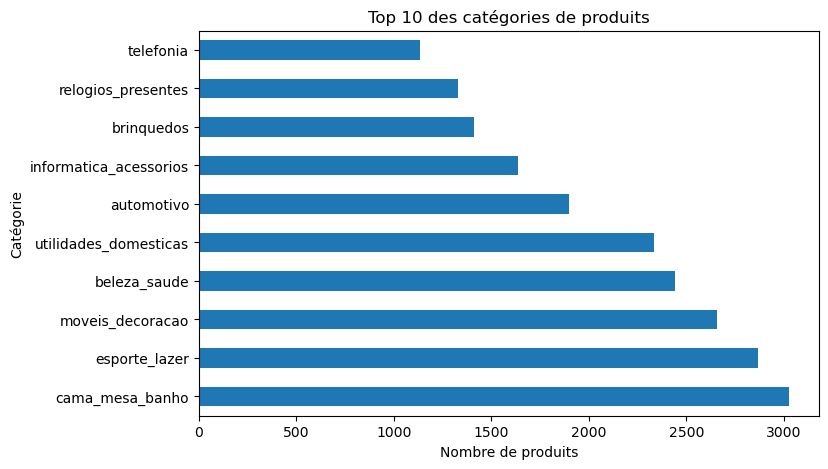

In [ ]:
# Graphique des 10 catégories de produits les plus représentées.
products["product_category_name"].value_counts().head(10).plot(kind="barh", figsize=(8, 5))
plt.title("Top 10 des catégories de produits")
plt.xlabel("Nombre de produits")
plt.ylabel("Catégorie")
plt.show()

## 16. Analyse géographique des clients

In [ ]:
# On affiche les 10 États avec le plus grand nombre de clients.
customers["customer_state"].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

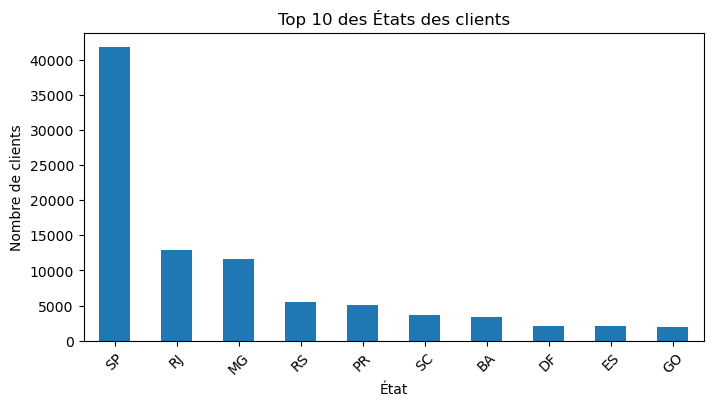

In [ ]:
# Graphique des 10 États avec le plus grand nombre de clients.
customers["customer_state"].value_counts().head(10).plot(kind="bar", figsize=(8, 4))
plt.title("Top 10 des États des clients")
plt.xlabel("État")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=45)
plt.show()

## 17. Analyse géographique des vendeurs

In [ ]:
# On affiche les 10 États avec le plus grand nombre de vendeurs.
sellers["seller_state"].value_counts().head(10)

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64

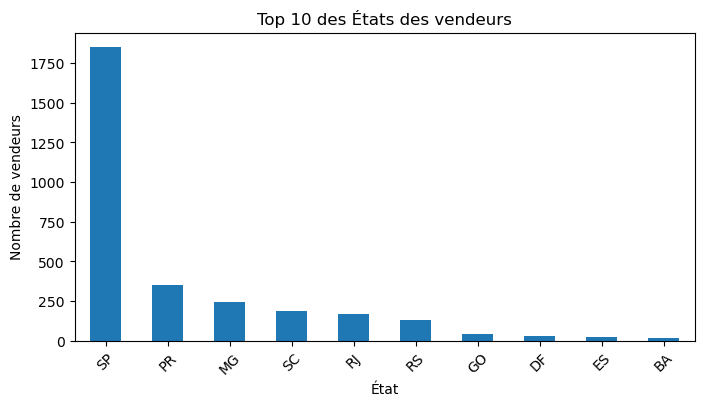

In [ ]:
# Graphique des 10 États avec le plus grand nombre de vendeurs.
sellers["seller_state"].value_counts().head(10).plot(kind="bar", figsize=(8, 4))
plt.title("Top 10 des États des vendeurs")
plt.xlabel("État")
plt.ylabel("Nombre de vendeurs")
plt.xticks(rotation=45)
plt.show()

## 18. Analyse du dataset de géolocalisation

In [ ]:
# Statistiques descriptives du dataset de géolocalisation.
geolocation.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [ ]:
# Répartition des observations de géolocalisation par État.
geolocation["geolocation_state"].value_counts().head(10)

geolocation_state
SP    404268
MG    126336
RJ    121169
RS     61851
PR     57859
SC     38328
BA     36045
GO     20139
ES     16748
PE     16432
Name: count, dtype: int64

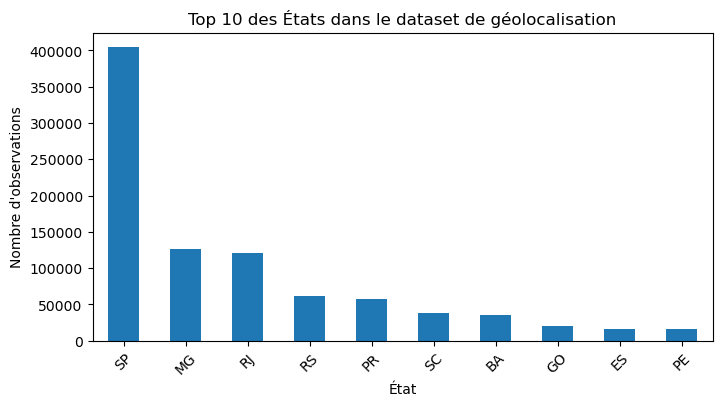

In [ ]:
# Graphique des États les plus présents dans le dataset de géolocalisation.
geolocation["geolocation_state"].value_counts().head(10).plot(kind="bar", figsize=(8, 4))
plt.title("Top 10 des États dans le dataset de géolocalisation")
plt.xlabel("État")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=45)
plt.show()

## 19. Analyse du fichier de traduction des catégories

In [ ]:
# Aperçu du fichier de traduction.
translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
# Dimensions du fichier de traduction.
translation.shape

(71, 2)

## 20. Conclusion de l'EDA

Cette première analyse exploratoire permet de mieux comprendre la structure générale du dataset Olist.

Principaux constats :

1. Le projet repose sur 9 datasets complémentaires.
2. Les commandes, les paiements, les articles commandés et les avis clients sont les tables centrales du projet.
3. La variable `review_score` est essentielle pour l'analyse de la satisfaction client.
4. Les colonnes `price` et `freight_value` permettent d'étudier les aspects économiques des commandes.
5. Les variables géographiques des clients et des vendeurs permettent d'analyser la répartition spatiale de l'activité.
6. Les valeurs manquantes devront être étudiées plus précisément dans une étape ultérieure.

Cette EDA constitue une première base académique avant les étapes de jointures, de nettoyage, de modélisation et de machine learning.